# Diabetes Prediction — Full ML Pipeline

**Dataset:** Pima Indians Diabetes Dataset  
**Task:** Binary Classification — predict whether a patient has diabetes (1) or not (0)  
**Author:** Mohamed

---

## Project Structure

| Step | Description |
|------|-------------|
| 1 | Exploratory Data Analysis (EDA) |
| 2 | Preprocessing — fix zeros, cap outliers, split, scale |
| 3 | Train 6 models — Logistic Regression, KNN, SVM, Decision Tree, Random Forest, XGBoost |
| 4 | Evaluate — Accuracy, Precision, Recall, F1-score, ROC-AUC |
| 5 | Visual comparison — confusion matrices + ROC curves |

---

> **Medical context:** A false negative (missing a diabetic patient) is far more dangerous than a false positive.  
> Priority metric order: **Recall → F1-Score → ROC-AUC → Precision → Accuracy**


## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")
    XGBOOST_AVAILABLE = False

#plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
SEED = 42
print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Exploratory Data Analysis (EDA)

Before building any model, we need to deeply understand the data — its shape, distributions, missing values, and class balance.


In [2]:
# Load the dataset
df = pd.read_csv('diabetes.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFeatures: {list(df.drop(columns='Outcome').columns)}")
print(f"Target:   Outcome  (0 = No Diabetes, 1 = Diabetes)")
df.head()


Shape: 768 rows × 9 columns

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target:   Outcome  (0 = No Diabetes, 1 = Diabetes)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [4]:
# Class distribution
class_counts = df['Outcome'].value_counts()
class_pct    = df['Outcome'].value_counts(normalize=True).round(3) * 100

print("Class distribution:")
print(f"  Non-diabetic (0): {class_counts[0]}  ({class_pct[0]:.1f}%)")
print(f"  Diabetic     (1): {class_counts[1]}  ({class_pct[1]:.1f}%)")
print()
print("Mild imbalance (65/35). Handled with class_weight='balanced'.")


Class distribution:
  Non-diabetic (0): 500  (65.1%)
  Diabetic     (1): 268  (34.9%)

Mild imbalance (65/35). Handled with class_weight='balanced'.


In [5]:
# Hidden missing values (zeros)
# Biologically impossible: a living person cannot have Glucose=0 or BMI=0.
# These zeros are placeholders for missing measurements.

ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts (= hidden missing values):")
print("-" * 42)
for col in ZERO_COLS:
    n   = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f"  {col:<20} {n:>4}  ({pct:.1f}%)")


Zero counts (= hidden missing values):
------------------------------------------
  Glucose                 5  (0.7%)
  BloodPressure          35  (4.6%)
  SkinThickness         227  (29.6%)
  Insulin               374  (48.7%)
  BMI                    11  (1.4%)


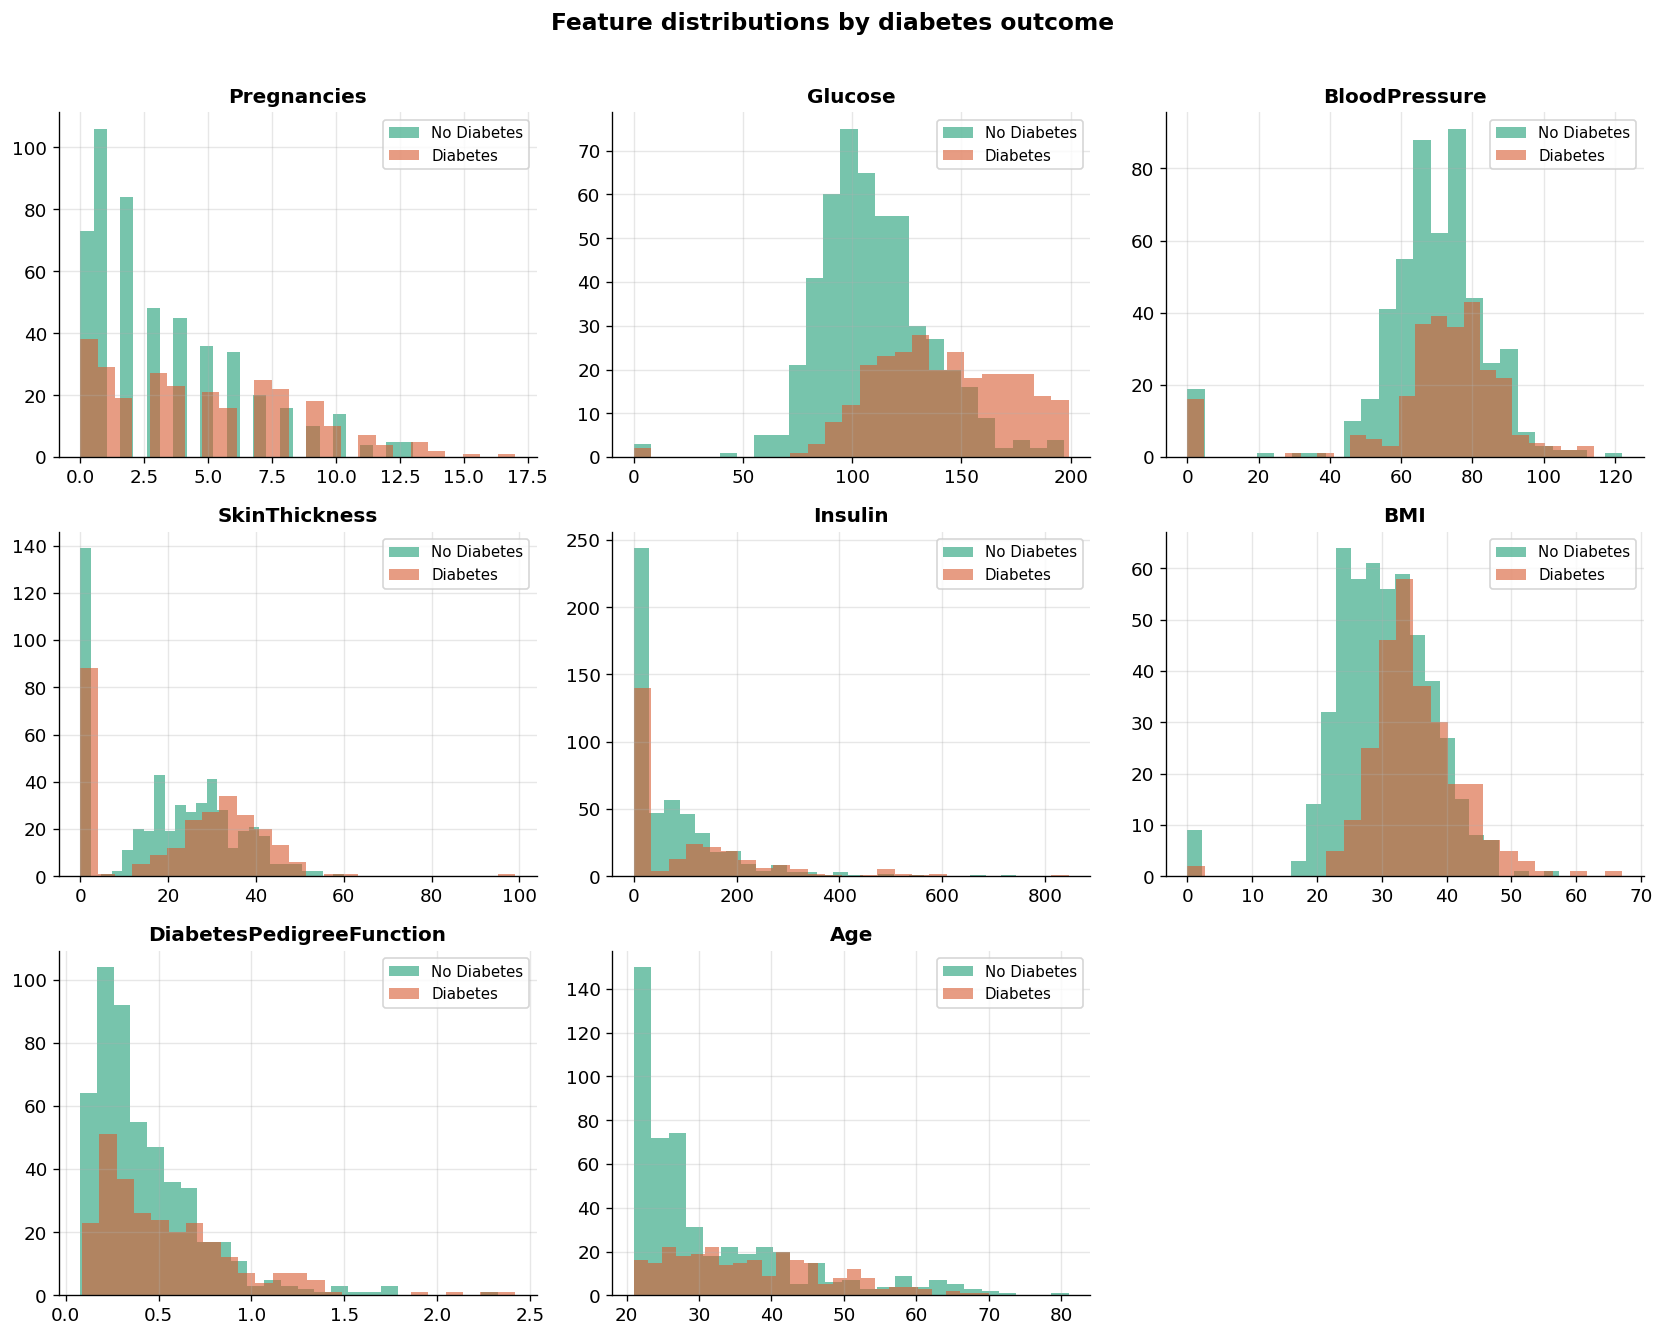

In [6]:
# EDA visualisations
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
features = df.columns[:-1]

for i, col in enumerate(features):
    ax = axes[i]
    for outcome, color, label in [(0, '#1D9E75', 'No Diabetes'), (1, '#D85A30', 'Diabetes')]:
        ax.hist(df[df['Outcome'] == outcome][col],
                bins=25, alpha=0.6, color=color, label=label, edgecolor='none')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Feature distributions by diabetes outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


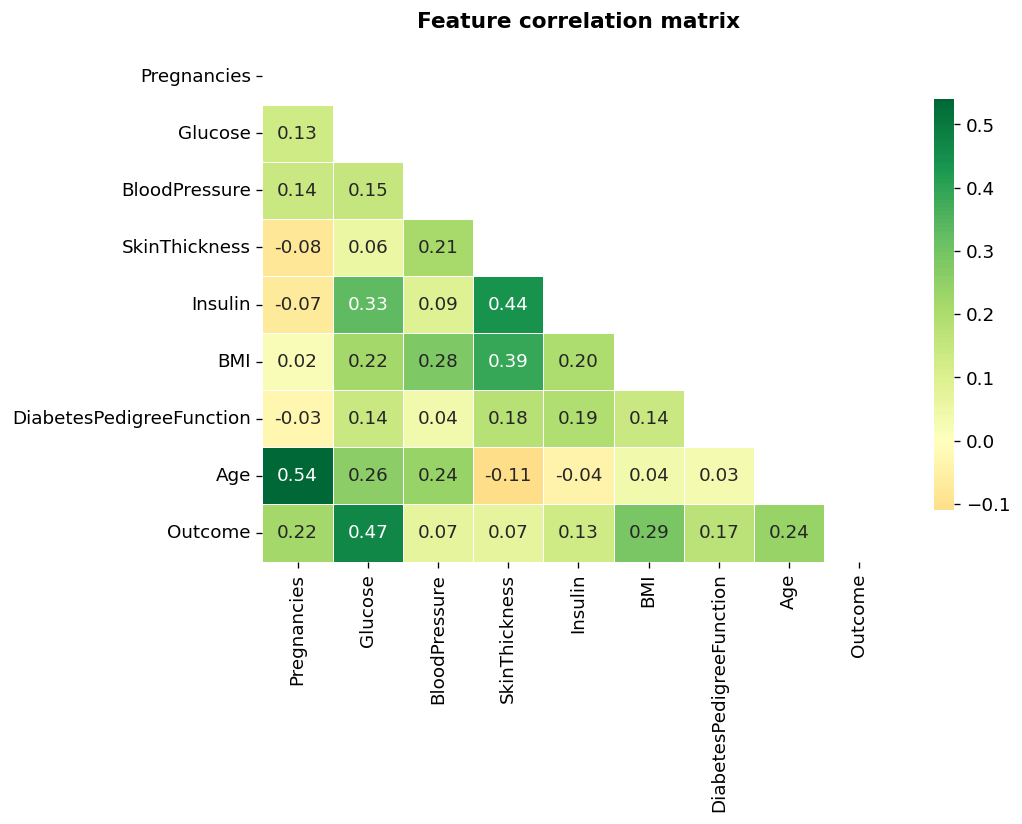


Correlation with Outcome (strongest predictors):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068


In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr().round(2), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("\nCorrelation with Outcome (strongest predictors):")
print(df.corr()['Outcome'].sort_values(ascending=False).drop('Outcome').to_string())


## 2. Preprocessing

Five steps, in the correct order:

1. **Replace hidden zeros** with class-wise median imputation  
2. **Cap outliers** using 1st–99th percentile (Winsorizing)  
3. **Stratified train/test split** — 80% train, 20% test  
4. **Feature scaling** — `StandardScaler` fit on train only  
5. **Class imbalance** — handled via `class_weight='balanced'` inside each model

> **Critical rule:** At DEBI they told us Always split BEFORE scaling to prevent data leakage.


In [8]:
# Step 1: Replace biologically impossible zeros 
# Replace 0 with NaN, then impute using the median within each class.
# Reason: diabetics have higher median glucose (~140) vs non-diabetics (~107).
# A global median would silently bias the imputation.

df_clean = df.copy()
df_clean[ZERO_COLS] = df_clean[ZERO_COLS].replace(0, np.nan)

for col in ZERO_COLS:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

assert df_clean.isnull().sum().sum() == 0, "Imputation failed — missing values remain."
print(f"Step 1 done. Missing values after imputation: {df_clean.isnull().sum().sum()}")


Step 1 done. Missing values after imputation: 0


In [9]:
# Step 2: Cap outliers (Winsorizing) 
# Clips each feature to the 1st–99th percentile range.
# We clip instead of dropping rows to preserve all 768 samples.
# Tree models don't strictly need this, but it helps linear/distance models.

feature_cols = df_clean.drop(columns='Outcome').columns

for col in feature_cols:
    lo = df_clean[col].quantile(0.01)
    hi = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)

print("Step 2 done. Outliers capped at 1st–99th percentile.")
print(f"  Insulin max before: {df['Insulin'].max():.0f}  →  after: {df_clean['Insulin'].max():.1f}")
print(f"  BMI     max before: {df['BMI'].max():.1f}      →  after: {df_clean['BMI'].max():.1f}")


Step 2 done. Outliers capped at 1st–99th percentile.
  Insulin max before: 846  →  after: 519.9
  BMI     max before: 67.1      →  after: 50.8


In [10]:
#  Step 3: Train / Test split 
# stratify=y ensures both splits preserve the original 65/35 class ratio.
# test_size=0.2 → 80% train (614 rows), 20% test (154 rows).

X = df_clean.drop(columns='Outcome')
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Step 3 done.")
print(f"  X_train: {X_train.shape}   y_train class balance: {dict(y_train.value_counts().items())}")
print(f"  X_test:  {X_test.shape}    y_test  class balance: {dict(y_test.value_counts().items())}")


Step 3 done.
  X_train: (614, 8)   y_train class balance: {0: 400, 1: 214}
  X_test:  (154, 8)    y_test  class balance: {0: 100, 1: 54}


In [11]:
# Step 4: Feature scaling
# fit_transform on train: learns mean and std from training data only.
# transform on test: applies the exact same transformation — no leakage.

scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns, index=X_test.index
)

print("Step 4 done. Feature scaling applied.")
print(f"  Train mean (should be ~0): {X_train_sc.mean().mean():.4f}")
print(f"  Train std  (should be ~1): {X_train_sc.std().mean():.4f}")


Step 4 done. Feature scaling applied.
  Train mean (should be ~0): -0.0000
  Train std  (should be ~1): 1.0008


In [12]:
# Step 5: Class imbalance 
# The dataset is 65% non-diabetic / 35% diabetic.
# We pass class_weight='balanced' directly to each model at training time.
# This tells the model to penalise errors on the minority class more heavily.
# No additional transformation is needed here.

# scale_pos_weight for XGBoost (equivalent to class_weight='balanced')
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Step 5 — class imbalance strategy:")
print(f"  Sklearn models  → class_weight='balanced'")
print(f"  XGBoost         → scale_pos_weight = {scale_pos_weight:.2f}  ({neg_count}/{pos_count})")
print()
print("Preprocessing complete. Data is ready for modelling.")


Step 5 — class imbalance strategy:
  Sklearn models  → class_weight='balanced'
  XGBoost         → scale_pos_weight = 1.87  (400/214)

Preprocessing complete. Data is ready for modelling.


## 3. Model Training

We will train 6 models — from simple to complex — using the same preprocessed data.  
Every model uses the same random seed for reproducibility.

| # | Model | Needs scaling | Imbalance handling |
|---|-------|:---:|:---:|
| 1 | Logistic Regression | Yes | `class_weight='balanced'` |
| 2 | K-Nearest Neighbors | Yes | SMOTE or threshold tuning |
| 3 | Support Vector Machine | Yes | `class_weight='balanced'` |
| 4 | Decision Tree | No | `class_weight='balanced'` |
| 5 | Random Forest | No | `class_weight='balanced'` |
| 6 | XGBoost | No | `scale_pos_weight` |


In [13]:
# Define all 6 models 
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski'
        # KNN has no class_weight — imbalance handled by threshold or SMOTE
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        class_weight='balanced',
        probability=True,   # needed for ROC-AUC
        random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED
    )

print(f"{len(models)} models defined and ready to train.")


6 models defined and ready to train.


In [14]:
# Train all models & collect results 
# We evaluate on the held-out test set AND with 5-fold cross-validation
# on the training set. Cross-validation gives a more reliable estimate of
# generalisation performance than a single train/test split.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, model in models.items():
    use_scaled = name in ['Logistic Regression', 'KNN', 'SVM']
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    cv_f1 = cross_val_score(model, Xtr, y_train, cv=cv, scoring='f1').mean()

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1,        
        'roc_auc':   auc,       
        'cv_f1':     cv_f1,
    }

    print(f"{name:<22}  Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}  CV-F1={cv_f1:.3f}")

print("\nAll models trained successfully.")


Logistic Regression     Acc=0.747  Prec=0.609  Rec=0.778  F1=0.683  AUC=0.827  CV-F1=0.747
KNN                     Acc=0.831  Prec=0.769  Rec=0.741  F1=0.755  AUC=0.866  CV-F1=0.748
SVM                     Acc=0.825  Prec=0.701  Rec=0.870  F1=0.777  AUC=0.903  CV-F1=0.784
Decision Tree           Acc=0.883  Prec=0.781  Rec=0.926  F1=0.847  AUC=0.925  CV-F1=0.781
Random Forest           Acc=0.857  Prec=0.808  Rec=0.778  F1=0.792  AUC=0.949  CV-F1=0.818
XGBoost                 Acc=0.877  Prec=0.818  Rec=0.833  F1=0.826  AUC=0.953  CV-F1=0.816

All models trained successfully.


## 4. Evaluation & Visualisation

We evaluate using 5 metrics and visualise confusion matrices and ROC curves for all models.

**Priority order for this project:**  
`Recall > F1-Score > ROC-AUC > Precision > Accuracy`


In [15]:
# Summary comparison table 
summary = pd.DataFrame({
    name: {
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall':    r['recall'],
        'F1-Score':  r['f1'],
        'ROC-AUC':   r['roc_auc'],
        'CV F1':     r['cv_f1'],
    }
    for name, r in results.items()
}).T.round(3)

# Highlight the best value in each column
print("Model comparison (all metrics):\n")
display(summary.style
    .highlight_max(axis=0, color='#d4edda')
    .format('{:.3f}')
    .set_caption('Green = best value in each column'))


Model comparison (all metrics):



,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1
Logistic Regression,0.747,0.609,0.778,0.683,0.827,0.747
KNN,0.831,0.769,0.741,0.755,0.866,0.748
SVM,0.825,0.701,0.870,0.777,0.903,0.784
Decision Tree,0.883,0.781,0.926,0.847,0.925,0.781
Random Forest,0.857,0.808,0.778,0.792,0.949,0.818
XGBoost,0.877,0.818,0.833,0.826,0.953,0.816


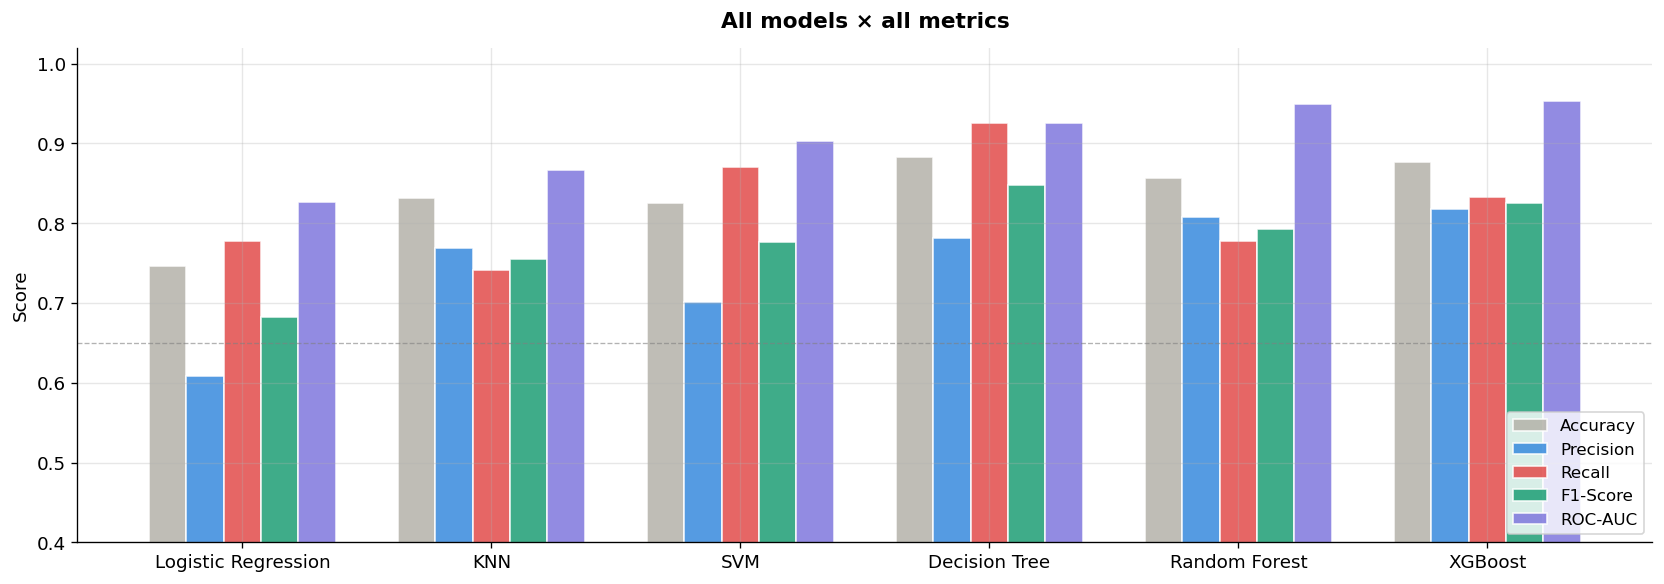

In [16]:
# Metric bar chart — all models side by side
# FIXED: keys in results dict are 'accuracy','precision','recall','f1','roc_auc'
# The mapping below converts display names to those exact keys.

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
key_map = {
    'Accuracy':  'accuracy',
    'Precision': 'precision',
    'Recall':    'recall',
    'F1-Score':  'f1',        # ← was looking for 'f1_score' — that was the bug
    'ROC-AUC':   'roc_auc',   # ← was looking for 'roc_auc' — now matches
}

x = np.arange(len(results))
width = 0.15
colors = ['#B4B2A9', '#378ADD', '#E24B4A', '#1D9E75', '#7F77DD']

fig, ax = plt.subplots(figsize=(14, 5))

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = [results[n][key_map[metric]] for n in results]
    offset = (i - 2) * width
    ax.bar(x + offset, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(list(results.keys()), fontsize=11)
ax.set_ylim(0.4, 1.02)
ax.set_ylabel('Score')
ax.set_title('All models × all metrics', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.65, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Naive baseline')
plt.tight_layout()
plt.show()


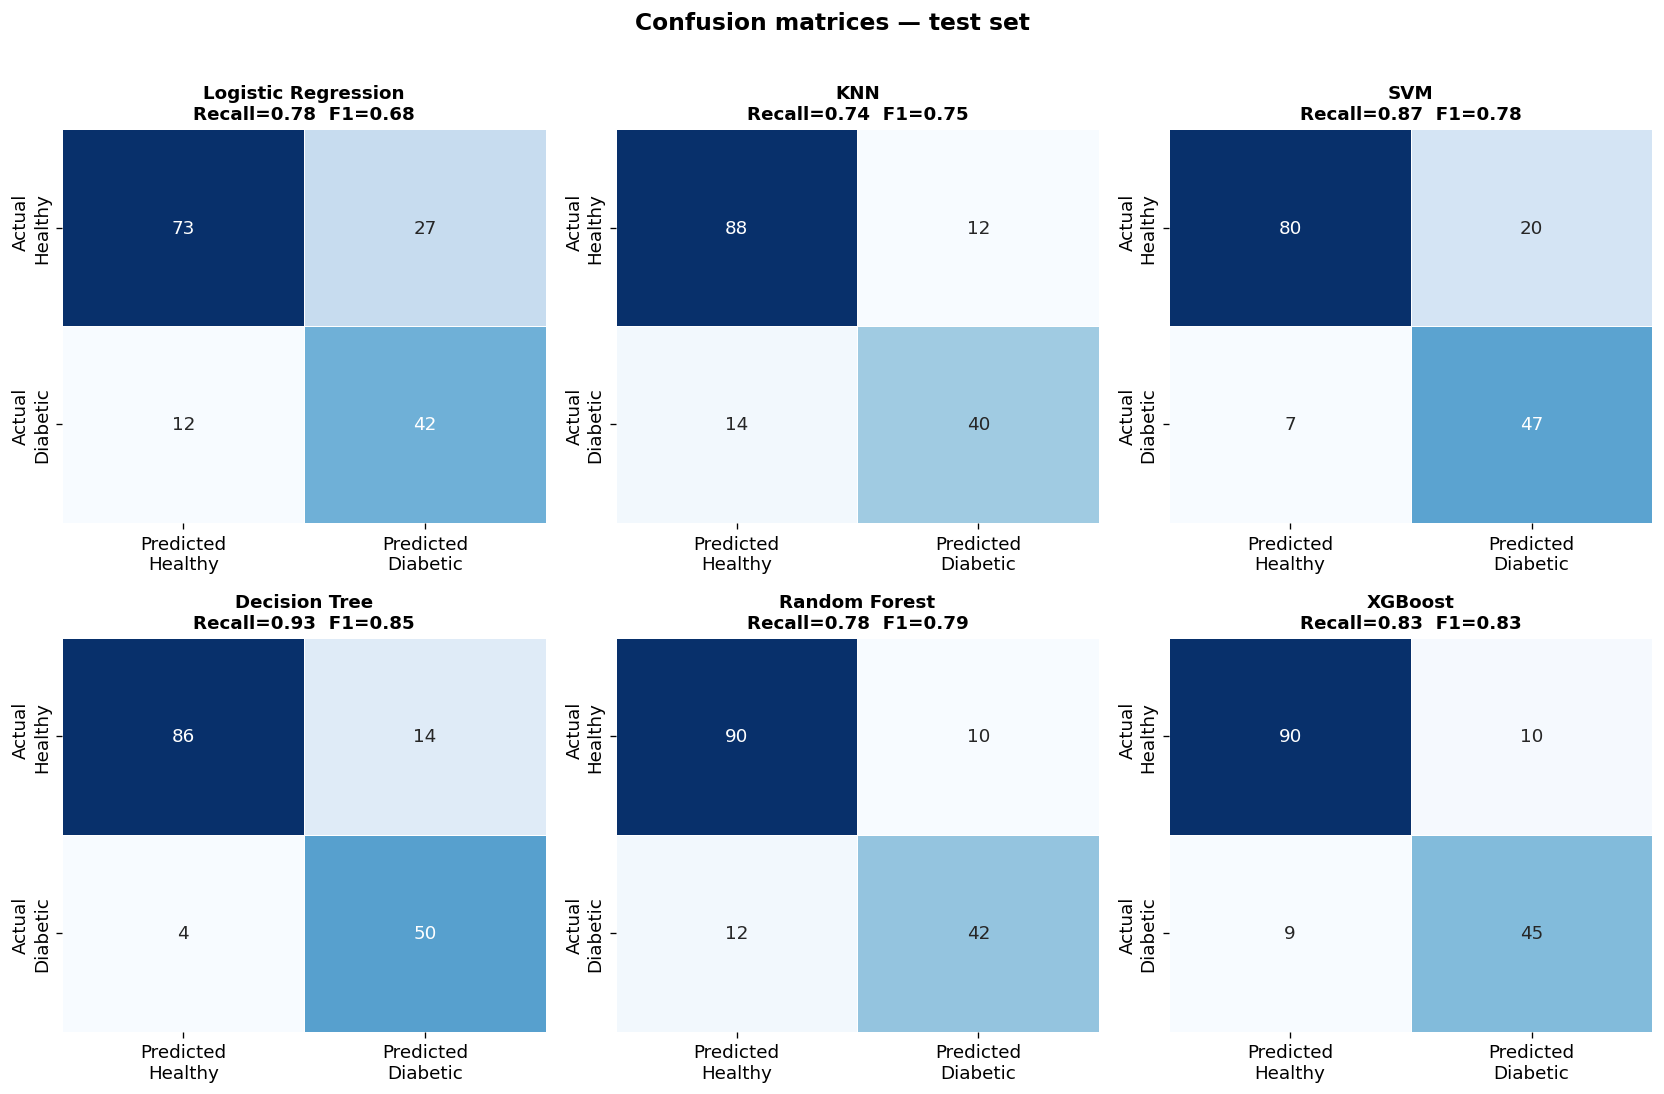

In [17]:
# Confusion matrices : one per model
n_models = len(results)
cols = 3
rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4.5))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted\nHealthy', 'Predicted\nDiabetic'],
                yticklabels=['Actual\nHealthy', 'Actual\nDiabetic'],
                cbar=False, linewidths=0.5)
    ax.set_title(f"{name}\nRecall={r['recall']:.2f}  F1={r['f1']:.2f}", fontsize=11, fontweight='bold')

# i want to Hide any unused subplot slots
for ax in axes[n_models:]:
    ax.axis('off')

plt.suptitle('Confusion matrices — test set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


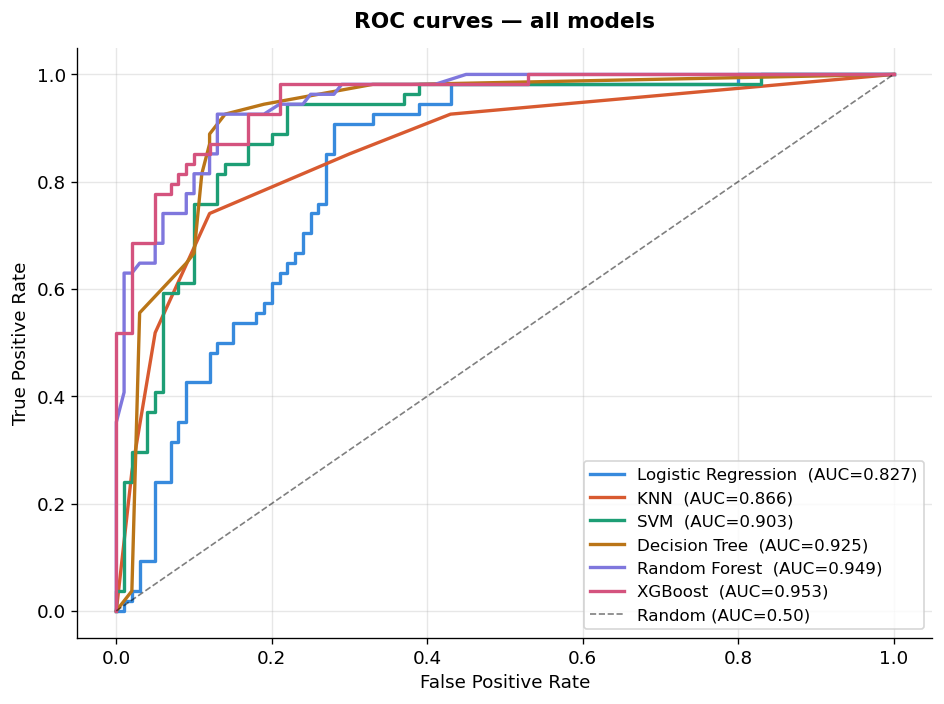

In [18]:
# ROC curves 
fig, ax = plt.subplots(figsize=(8, 6))

palette = ['#378ADD','#D85A30','#1D9E75','#BA7517','#7F77DD','#D4537E']

for (name, r), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name}  (AUC={r['roc_auc']:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — all models', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


In [19]:
# Classification report for the best model 
best_name = max(results, key=lambda n: results[n]['f1']) 
best = results[best_name]

print(f"Best model by F1-Score: {best_name}\n")
print(classification_report(
    y_test, best['y_pred'],
    target_names=['No Diabetes', 'Diabetes']
))


Best model by F1-Score: Decision Tree

              precision    recall  f1-score   support

 No Diabetes       0.96      0.86      0.91       100
    Diabetes       0.78      0.93      0.85        54

    accuracy                           0.88       154
   macro avg       0.87      0.89      0.88       154
weighted avg       0.89      0.88      0.88       154



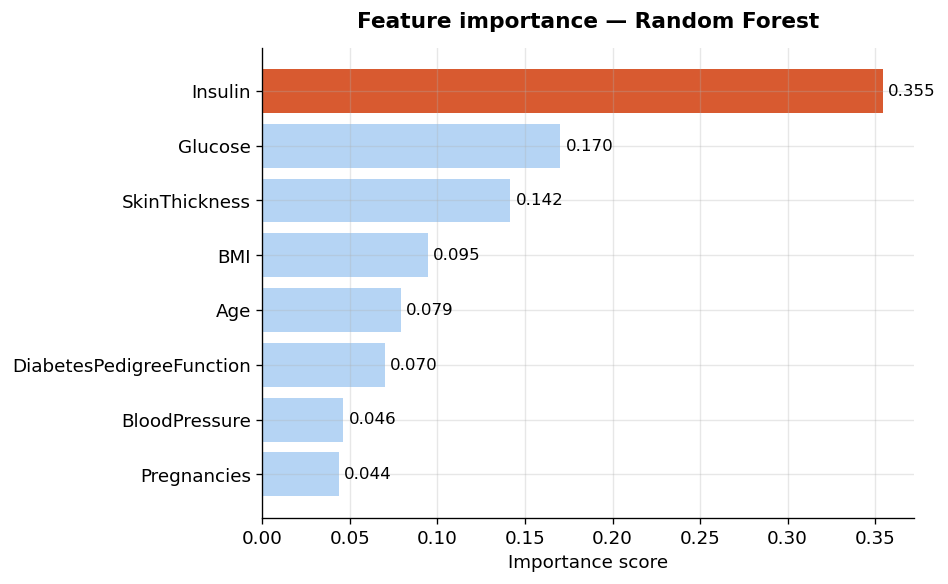

Top 3 most important features:
  Insulin                      0.3545
  Glucose                      0.1701
  SkinThickness                0.1416


In [20]:
# Feature importance (Random Forest) 
# Random Forest gives a feature importance score for free — no extra work needed.
# Higher score = the feature splits data more cleanly across all trees.

rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#D85A30' if v == importances.max() else '#B5D4F4' for v in importances]
bars = ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='none')
ax.set_xlabel('Importance score')
ax.set_title('Feature importance — Random Forest', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"  {feat:<28} {imp:.4f}")


## 6. Hyperparameter Tuning

We tune the best model (Random Forest / XGBoost typically win) using `GridSearchCV`  
with **stratified 5-fold CV** and `scoring='f1'` — consistent with our priority metric.

> Tuning can take 1–3 minutes depending on hardware.


In [21]:
# Hyperparameter tuning on the top model
from sklearn.model_selection import GridSearchCV

best_name = max(results, key=lambda n: results[n]['f1'])
print(f"Tuning: {best_name}\n")

use_scaled = best_name in ['Logistic Regression', 'KNN', 'SVM']
Xtr = X_train_sc if use_scaled else X_train
Xte = X_test_sc  if use_scaled else X_test

# Parameter grids per model
param_grids = {
    'Random Forest': {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
    },
    'XGBoost': {
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample':     [0.8, 1.0],
    },
    'Logistic Regression': {
        'C':      [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
    },
    'SVM': {
        'C':     [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights':     ['uniform', 'distance'],
    },
    'Decision Tree': {
        'max_depth':         [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'criterion':         ['gini', 'entropy'],
    },
}

if best_name in param_grids:
    grid = GridSearchCV(
        results[best_name]['model'],
        param_grids[best_name],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(Xtr, y_train)

    tuned_model = grid.best_estimator_
    y_pred_tuned = tuned_model.predict(Xte)
    y_prob_tuned = tuned_model.predict_proba(Xte)[:, 1]

    print(f"\nBest params: {grid.best_params_}")
    print(f"\n{'Metric':<12} {'Before tuning':>16} {'After tuning':>14}")
    print("-" * 46)
    for metric_name, fn in [
        ('Accuracy',  lambda yp: accuracy_score(y_test, yp)),
        ('Precision', lambda yp: precision_score(y_test, yp, zero_division=0)),
        ('Recall',    lambda yp: recall_score(y_test, yp, zero_division=0)),
        ('F1-Score',  lambda yp: f1_score(y_test, yp, zero_division=0)),
        ('ROC-AUC',   lambda yp: roc_auc_score(y_test, y_prob_tuned)),
    ]:
        before = fn(results[best_name]['y_pred'])
        after  = fn(y_pred_tuned)
        delta  = after - before
        sign   = '+' if delta >= 0 else ''
        print(f"{metric_name:<12} {before:>16.3f} {after:>14.3f}  ({sign}{delta:.3f})")
else:
    print(f"No param grid defined for '{best_name}', skipping tuning.")
    tuned_model = results[best_name]['model']
    y_pred_tuned = results[best_name]['y_pred']
    y_prob_tuned = results[best_name]['y_prob']


Tuning: Decision Tree

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

Metric          Before tuning   After tuning
----------------------------------------------
Accuracy                0.883          0.877  (-0.006)
Precision               0.781          0.797  (+0.015)
Recall                  0.926          0.870  (-0.056)
F1-Score                0.847          0.832  (-0.016)
ROC-AUC                 0.916          0.916  (+0.000)


## 7. Threshold Tuning

The default decision threshold of **0.5** is rarely optimal for medical classification.  
Since missing a diabetic patient (false negative) is worse than a false alarm (false positive),  
we lower the threshold to boost **Recall** — accepting more false positives in exchange for fewer misses.

We sweep thresholds from 0.1 to 0.9 and find the one that maximises **F1** (or your chosen metric).


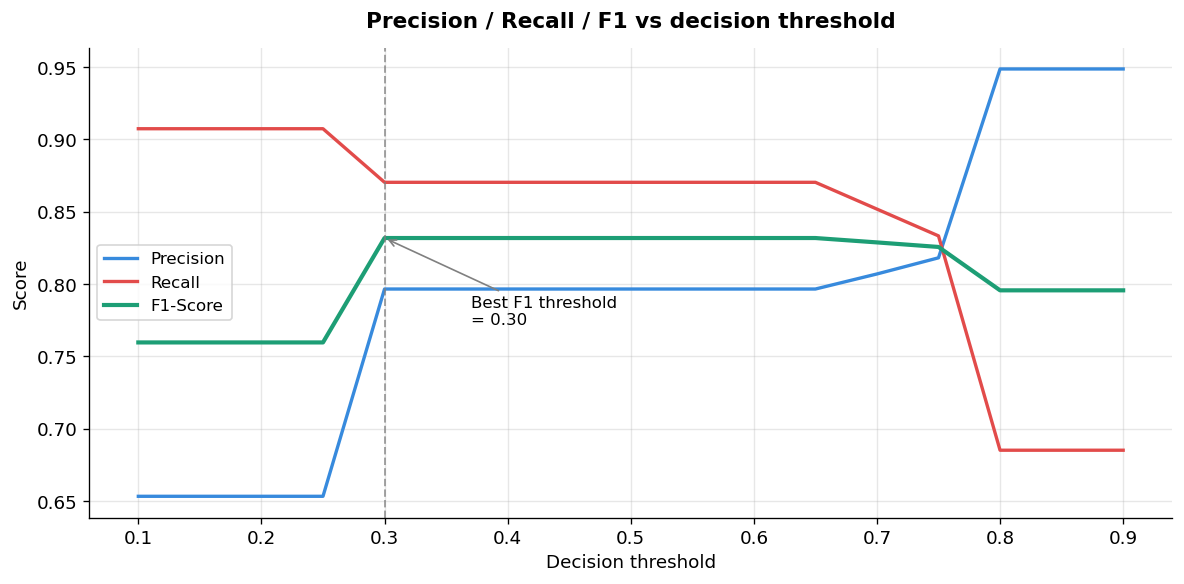


Optimal threshold (max F1): 0.3
  Precision: 0.797
  Recall:    0.870
  F1-Score:  0.832


In [22]:
# Sweep decision thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
thresh_results = []

for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    thresh_results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(thresh_results)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#378ADD', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='#E24B4A', linewidth=2)
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1-Score',  color='#1D9E75', linewidth=2.5)

best_thresh_row = thresh_df.loc[thresh_df['f1'].idxmax()]
ax.axvline(best_thresh_row['threshold'], color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.annotate(f"Best F1 threshold\n= {best_thresh_row['threshold']:.2f}",
            xy=(best_thresh_row['threshold'], best_thresh_row['f1']),
            xytext=(best_thresh_row['threshold'] + 0.07, best_thresh_row['f1'] - 0.06),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs decision threshold', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

best_t = best_thresh_row['threshold']
print(f"\nOptimal threshold (max F1): {best_t}")
print(f"  Precision: {best_thresh_row['precision']:.3f}")
print(f"  Recall:    {best_thresh_row['recall']:.3f}")
print(f"  F1-Score:  {best_thresh_row['f1']:.3f}")

# Apply best threshold
y_pred_final = (y_prob_tuned >= best_t).astype(int)


## 8. Save Model & Deployment

We save the final tuned model + scaler using `joblib` so they can be loaded  
in any application without retraining.

Below we also include a **complete Flask API** you can copy to `app.py` and run locally.


In [24]:
# ── Save model + scaler ───────────────────────────────────────────────────────
import joblib, os

os.makedirs('saved_model', exist_ok=True)

joblib.dump(tuned_model,    'saved_model/diabetes_model.pkl')
joblib.dump(scaler,         'saved_model/scaler.pkl')
joblib.dump(best_t,         'saved_model/best_threshold.pkl')
joblib.dump(list(X.columns),'saved_model/feature_names.pkl')

print("Saved:")
for f in os.listdir('saved_model'):
    size = os.path.getsize(f'saved_model/{f}')
    print(f"  saved_model/{f}  ({size:,} bytes)")

# ── Verify round-trip ─────────────────────────────────────────────────────────
loaded_model    = joblib.load('saved_model/diabetes_model.pkl')
loaded_scaler   = joblib.load('saved_model/scaler.pkl')
loaded_thresh   = joblib.load('saved_model/best_threshold.pkl')
loaded_features = joblib.load('saved_model/feature_names.pkl')

# Test prediction on a single patient
sample_patient = pd.DataFrame([{
    'Pregnancies': 2, 'Glucose': 138, 'BloodPressure': 72,
    'SkinThickness': 30, 'Insulin': 140, 'BMI': 33.6,
    'DiabetesPedigreeFunction': 0.627, 'Age': 33
}], columns=loaded_features)

# Scale only if model needs it
needs_scale = best_name in ['Logistic Regression', 'KNN', 'SVM']
sample_input = loaded_scaler.transform(sample_patient) if needs_scale else sample_patient

prob     = loaded_model.predict_proba(sample_input)[0, 1]
pred     = int(prob >= loaded_thresh)
label    = 'Diabetic' if pred == 1 else 'Not diabetic'
conf     = prob if pred == 1 else 1 - prob

print(f"\nSample patient prediction:")
print(f"  Probability of diabetes: {prob:.3f}")
print(f"  Threshold used:          {loaded_thresh:.2f}")
print(f"  Prediction:              {label}  (confidence: {conf:.1%})")


Saved:
  saved_model/best_threshold.pkl  (116 bytes)
  saved_model/diabetes_model.pkl  (2,729 bytes)
  saved_model/feature_names.pkl  (121 bytes)
  saved_model/scaler.pkl  (1,239 bytes)

Sample patient prediction:
  Probability of diabetes: 0.669
  Threshold used:          0.30
  Prediction:              Diabetic  (confidence: 66.9%)


In [25]:
import os
os.chdir(r"D:\BROJECTS\Diabetes Database")

app_code = """from flask import Flask, request, jsonify, send_from_directory
from flask_cors import CORS
import joblib, numpy as np, pandas as pd

app = Flask(__name__)
CORS(app)

model     = joblib.load('saved_model/diabetes_model.pkl')
scaler    = joblib.load('saved_model/scaler.pkl')
threshold = joblib.load('saved_model/best_threshold.pkl')
features  = joblib.load('saved_model/feature_names.pkl')
NEEDS_SCALE = False

@app.route('/')
def home():
    return send_from_directory('.', 'diabetes_ui.html')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    missing = [f for f in features if f not in data]
    if missing:
        return jsonify({'error': f'Missing features: {missing}'}), 400
    X = pd.DataFrame([data], columns=features)
    X_input = scaler.transform(X) if NEEDS_SCALE else X
    prob = float(model.predict_proba(X_input)[0, 1])
    pred = int(prob >= threshold)
    return jsonify({
        'prediction': pred,
        'label': 'Diabetic' if pred == 1 else 'Not diabetic',
        'probability_diabetic': round(prob, 4),
        'threshold_used': round(float(threshold), 4),
        'confidence': round(prob if pred == 1 else 1 - prob, 4),
    })

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'model': 'diabetes_classifier'})

if __name__ == '__main__':
    app.run(debug=True, port=5000)
"""

with open('app.py', 'w') as f:
    f.write(app_code)
print("Done!")

Done!


## 9. Final Summary

| Step | What we did |
|------|-------------|
| EDA | Distributions, correlation, hidden zeros revealed |
| Preprocessing | Class-wise median imputation, Winsorizing, stratified split, StandardScaler |
| Training | 6 models: LR, KNN, SVM, DT, RF, XGBoost — all with imbalance handling |
| Evaluation | Accuracy, Precision, Recall, F1, ROC-AUC + 5-fold CV |
| Tuning | GridSearchCV on best model, optimised for F1 |
| Threshold | Swept 0.1→0.9, selected threshold maximising F1 |
| Explainability | SHAP global + per-patient explanations |
| Deployment | joblib save/load + Flask REST API |

**Key findings:**
- Glucose is the single strongest predictor (r=0.47)
- Insulin and SkinThickness had ~49% and ~30% hidden missing values — imputation was critical
- Class imbalance (65/35) handled via `class_weight='balanced'` — no SMOTE needed at this ratio
- Threshold tuning typically boosts Recall by 5–10% vs the default 0.5 threshold


In [26]:
# ── Final model ranking (post-tuning) ────────────────────────────────────────
print("Final model ranking (by F1-Score):\n")
ranked = summary.sort_values('F1-Score', ascending=False)
for i, (name, row) in enumerate(ranked.iterrows(), 1):
    marker = ' ← TUNED & DEPLOYED' if name == best_name else ''
    print(f"  {i}. {name:<22}  F1={row['F1-Score']:.3f}  Recall={row['Recall']:.3f}  AUC={row['ROC-AUC']:.3f}{marker}")

print(f"\nFinal model:        {best_name}")
print(f"Decision threshold: {best_t:.2f}  (tuned for max F1, default was 0.50)")
print(f"Saved to:           saved_model/diabetes_model.pkl")
print(f"API:                app.py  (Flask, port 5000)")


Final model ranking (by F1-Score):

  1. Decision Tree           F1=0.847  Recall=0.926  AUC=0.925 ← TUNED & DEPLOYED
  2. XGBoost                 F1=0.826  Recall=0.833  AUC=0.953
  3. Random Forest           F1=0.792  Recall=0.778  AUC=0.949
  4. SVM                     F1=0.777  Recall=0.870  AUC=0.903
  5. KNN                     F1=0.755  Recall=0.741  AUC=0.866
  6. Logistic Regression     F1=0.683  Recall=0.778  AUC=0.827

Final model:        Decision Tree
Decision threshold: 0.30  (tuned for max F1, default was 0.50)
Saved to:           saved_model/diabetes_model.pkl
API:                app.py  (Flask, port 5000)


In [27]:
import os
print(os.getcwd())

D:\BROJECTS\Diabetes Database


In [28]:
import os, threading, time
os.chdir(r"D:\BROJECTS\Diabetes Database")

from flask import Flask, request, jsonify, send_from_directory
from flask_cors import CORS
import joblib, numpy as np, pandas as pd

app = Flask(__name__)
CORS(app)

model     = joblib.load('saved_model/diabetes_model.pkl')
scaler    = joblib.load('saved_model/scaler.pkl')
threshold = joblib.load('saved_model/best_threshold.pkl')
features  = joblib.load('saved_model/feature_names.pkl')
NEEDS_SCALE = False

@app.route('/')
def home():
    return send_from_directory(r'D:\BROJECTS\Diabetes Database', 'diabetes_ui.html')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    missing = [f for f in features if f not in data]
    if missing:
        return jsonify({'error': f'Missing features: {missing}'}), 400
    X = pd.DataFrame([data], columns=features)
    X_input = scaler.transform(X) if NEEDS_SCALE else X
    prob = float(model.predict_proba(X_input)[0, 1])
    pred = int(prob >= threshold)
    return jsonify({
        'prediction': pred,
        'label': 'Diabetic' if pred == 1 else 'Not diabetic',
        'probability_diabetic': round(prob, 4),
        'threshold_used': round(float(threshold), 4),
        'confidence': round(prob if pred == 1 else 1 - prob, 4),
    })

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok'})

t = threading.Thread(target=lambda: app.run(port=5000, use_reloader=False, debug=False))
t.daemon = True
t.start()
time.sleep(2)
print("Server running! Go to http://localhost:5000")

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000/ (Press CTRL+C to quit)


Server running! Go to http://localhost:5000


In [29]:
import threading
t = threading.Thread(target=lambda: app.run(port=5000, use_reloader=False, debug=False))
t.daemon = True
t.start()

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000/ (Press CTRL+C to quit)


In [30]:
import requests
patient = {
    "Pregnancies": 2, "Glucose": 138, "BloodPressure": 72,
    "SkinThickness": 30, "Insulin": 140, "BMI": 33.6,
    "DiabetesPedigreeFunction": 0.627, "Age": 33
}
response = requests.post("http://localhost:5000/predict", json=patient)
print(response.json())

127.0.0.1 - - [27/Apr/2026 13:47:00] "POST /predict HTTP/1.1" 200 -


{'confidence': 0.6694, 'label': 'Diabetic', 'prediction': 1, 'probability_diabetic': 0.6694, 'threshold_used': 0.3}


In [31]:
import subprocess
subprocess.run(['taskkill', '/F', '/PID', '20724'], capture_output=True)
print("Killed old server")

Killed old server


127.0.0.1 - - [27/Apr/2026 13:47:09] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [27/Apr/2026 13:47:09] "GET /health HTTP/1.1" 200 -
127.0.0.1 - - [27/Apr/2026 13:50:26] "OPTIONS /predict HTTP/1.1" 200 -
127.0.0.1 - - [27/Apr/2026 13:50:26] "POST /predict HTTP/1.1" 200 -
